In [ ]:
import os
import numpy as np
import librosa
from scipy.fftpack import dct
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, hamming_loss, classification_report
import pandas as pd


In [ ]:
# Parámetros generales
AUDIO_FOLDER = "padded"  
LABELS_FILE = "data.csv" 
SAMPLE_RATE = 22050  # Frecuencia de muestreo
N_MELS = 40  # Número de bandas Mel
N_DCT = 13  # Número de coeficientes de la Transformada Discreta del Coseno (DCT)

In [3]:
# Función para cargar etiquetas desde el archivo CSV
def load_labels(file_path):
    data = pd.read_csv(file_path)
    file_names = data["nombre"].values
    labels = data.iloc[:, 1:].values  # Suponiendo que las etiquetas están en columnas 1-9
    return dict(zip(file_names, labels))

# Función para extraer características (DCT de Mel-espectrograma)
def extract_features(audio_path, sample_rate=SAMPLE_RATE, n_mels=N_MELS, n_dct=N_DCT):
    y, sr = librosa.load(audio_path, sr=sample_rate)
    
    # Calcular el Mel-espectrograma
    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    
    # Convertir el espectrograma a escala logarítmica
    mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
    # Aplicar DCT sobre el eje de tiempo (eje 1)
    dct_features = dct(mel_db, axis=0, norm='ortho')[:n_dct]  # Normalización ortogonal
    
    return dct_features.flatten()  # Aplanar para usar como entrada del modelo

# Cargar datos y etiquetas
def load_data(audio_folder, labels_dict):
    X, y = [], []
    for file_name, labels in labels_dict.items():
        audio_path = os.path.join(audio_folder, file_name)
        if os.path.exists(audio_path):
            features = extract_features(audio_path)
            X.append(features)
            y.append(labels)
    return np.array(X), np.array(y)

In [ ]:
# Cargar etiquetas desde el archivo CSV
labels_dict = load_labels(LABELS_FILE)

# Extraer características de los audios
X, y = load_data(AUDIO_FOLDER, labels_dict)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Entrenar un modelo SVM multietiqueta
svm = SVC(kernel="linear", probability=True)
multi_svm = MultiOutputClassifier(svm)
multi_svm.fit(X_train, y_train)

# Evaluar el modelo
y_pred = multi_svm.predict(X_test)

In [9]:
# Calcular el accuracy independiente por cada etiqueta
accuracy_per_label = []
for i in range(y_train.shape[1]):
    acc = accuracy_score(y_test[:, i], y_pred[:, i])
    accuracy_per_label.append(acc)
    print(f"Etiqueta {i + 1}: Accuracy = {acc:.4f}")

# Métricas generales
print("\nHamming Loss (promedio de errores por etiqueta):", hamming_loss(y_test, y_pred))
print("\nReporte de clasificación por etiqueta:\n", classification_report(y_test, y_pred))

# Accuracy promedio (promedio de los accuracy individuales por etiqueta)
mean_accuracy = np.mean(accuracy_per_label)
print(f"\nMean Accuracy (Promedio por etiqueta): {mean_accuracy:.4f}")


Etiqueta 1: Accuracy = 0.7032
Etiqueta 2: Accuracy = 0.9465
Etiqueta 3: Accuracy = 0.6791
Etiqueta 4: Accuracy = 0.6925
Etiqueta 5: Accuracy = 0.6845
Etiqueta 6: Accuracy = 0.6578
Etiqueta 7: Accuracy = 0.7380
Etiqueta 8: Accuracy = 0.9011
Etiqueta 9: Accuracy = 0.7834

Hamming Loss (promedio de errores por etiqueta): 0.24598930481283424

Reporte de clasificación por etiqueta:
               precision    recall  f1-score   support

           0       0.57      0.61      0.59       130
           1       0.17      0.17      0.17        12
           2       0.59      0.57      0.58       145
           3       0.57      0.67      0.62       138
           4       0.49      0.57      0.52       114
           5       0.65      0.58      0.61       173
           6       0.53      0.53      0.53       104
           7       0.12      0.17      0.14        18
           8       0.49      0.49      0.49        79

   micro avg       0.54      0.57      0.56       913
   macro avg       0.46

C:\Users\mussi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mussi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [11]:
import joblib

# Guardar el modelo entrenado
joblib.dump(multi_svm, 'svm_model.joblib')

# Cargar el modelo entrenado
loaded_model = joblib.load('svm_model.joblib')

# Usar el modelo cargado para hacer predicciones
y_pred = loaded_model.predict(X_test)


Visualizar un audio

Forma del Mel-espectrograma: (40, 778)
Forma de los coeficientes DCT: (13, 778)


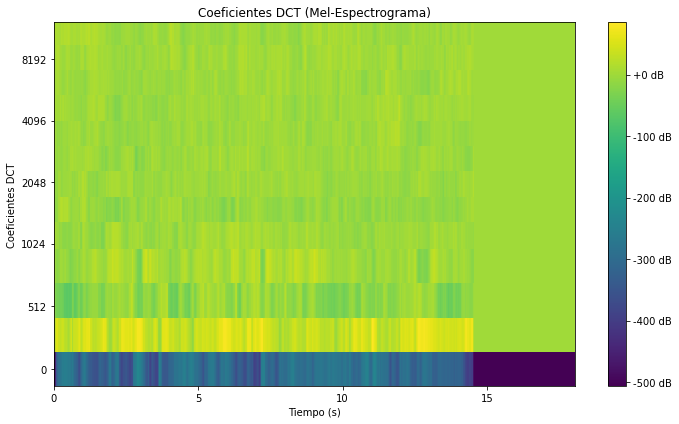

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.fftpack import dct

# Parámetros generales
AUDIO_PATH = "padded/13audio_22.wav"  # Cambia esto por la ruta de tu archivo
SAMPLE_RATE = 22050  # Frecuencia de muestreo
N_MELS = 40  # Número de bandas Mel
N_DCT = 13  # Número de coeficientes DCT

# Función para calcular DCT del Mel-espectrograma
def extract_dct_features(audio_path, sample_rate=SAMPLE_RATE, n_mels=N_MELS, n_dct=N_DCT):
    y, sr = librosa.load(audio_path, sr=sample_rate)
    
    # Calcular el Mel-espectrograma
    mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    
    # Convertir el espectrograma a escala logarítmica
    mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
    # Verificar la forma de Mel-espectrograma
    print(f"Forma del Mel-espectrograma: {mel_db.shape}")
    
    # Aplicar DCT sobre el eje de tiempo (eje 0)
    dct_features = dct(mel_db, axis=0, norm='ortho')[:n_dct, :]
    
    # Verificar la forma de DCT
    print(f"Forma de los coeficientes DCT: {dct_features.shape}")
    
    return dct_features

# Cargar el audio y calcular DCT
dct_features = extract_dct_features(AUDIO_PATH)

# Verificar si el resultado es válido para graficar
if dct_features.ndim != 2 or dct_features.shape[0] == 0 or dct_features.shape[1] == 0:
    raise ValueError("Los datos de DCT no tienen una forma válida para graficar.")

# Graficar los coeficientes DCT
plt.figure(figsize=(10, 6))
librosa.display.specshow(
    dct_features, sr=SAMPLE_RATE, x_axis='time', y_axis='mel', cmap='viridis'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Coeficientes DCT (Mel-Espectrograma)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Coeficientes DCT")
plt.tight_layout()
plt.show()

